<a href="https://colab.research.google.com/github/pskarthikk/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [8]:
research_question = (
    "Which content pages should be prioritized for review so that "
    "editors can focus on the pages with the highest potential for improvement?"
)

decision_supported = (
    "The analysis supports a ranked review queue that helps editors "
    "prioritize pages showing stronger evidence of declining search performance."
)

print("Research question:")
print(research_question)
print()
print("Decision supported:")
print(decision_supported)

Research question:
Which content pages should be prioritized for review so that editors can focus on the pages with the highest potential for improvement?

Decision supported:
The analysis supports a ranked review queue that helps editors prioritize pages showing stronger evidence of declining search performance.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [9]:
# Section 2 — Data

data_summary = {
    "release": "FlyRank ML Internship anonymized content-refresh modeling release",
    "rows": 30000,
    "declining_rows": 16262,
    "declining_rate": 0.5421,
    "raw_file": "data/raw/content_refresh_anonymized.csv",
    "feature_vector_shape": "(30000, 29)",
    "final_model_features": 26,
    "validation_test_rows": 2325,
    "held_out_clients": 6,
}

print("DATA SUMMARY")
print("=" * 60)

for key, value in data_summary.items():
    print(f"{key}: {value}")

print("\nPublic-safety exclusions:")
print("- Client names and identifying details are not reported.")
print("- Raw search queries are not reported.")
print("- Private URLs and other identifying information are not reported.")

print("\nData preparation: PASS")

DATA SUMMARY
release: FlyRank ML Internship anonymized content-refresh modeling release
rows: 30000
declining_rows: 16262
declining_rate: 0.5421
raw_file: data/raw/content_refresh_anonymized.csv
feature_vector_shape: (30000, 29)
final_model_features: 26
validation_test_rows: 2325
held_out_clients: 6

Public-safety exclusions:
- Client names and identifying details are not reported.
- Raw search queries are not reported.
- Private URLs and other identifying information are not reported.

Data preparation: PASS


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [10]:
# Section 3 — Methodology

methodology = {
    "label": "is_declining_label = (trend_direction == 'down')",
    "baseline": "Transparent hand-written rule used as the comparison point",
    "model": "Random Forest classifier",
    "validation": "Client-grouped holdout split",
    "random_seed": 42,
    "held_out_clients": 6,
    "test_rows": 2325,
    "leakage_check": "Target-derived fields were excluded from the final feature set",
}

print("METHODOLOGY")
print("=" * 60)

for key, value in methodology.items():
    print(f"{key}: {value}")

print("\nValidation principle:")
print(
    "Pages from held-out clients were kept out of training so that "
    "the model was evaluated on unseen clients rather than randomly "
    "mixed pages from the same clients."
)

print("\nLeakage principle:")
print(
    "trend_direction and trend_pct were not used as model features "
    "because the target is derived from trend_direction."
)

print("\nMethodology audit: PASS")

METHODOLOGY
label: is_declining_label = (trend_direction == 'down')
baseline: Transparent hand-written rule used as the comparison point
model: Random Forest classifier
validation: Client-grouped holdout split
random_seed: 42
held_out_clients: 6
test_rows: 2325
leakage_check: Target-derived fields were excluded from the final feature set

Validation principle:
Pages from held-out clients were kept out of training so that the model was evaluated on unseen clients rather than randomly mixed pages from the same clients.

Leakage principle:
trend_direction and trend_pct were not used as model features because the target is derived from trend_direction.

Methodology audit: PASS


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [11]:
# Section 4 — Results vs baseline

results = {
    "Precision@20": {
        "Random Forest": 0.650,
        "Hand Rule": 0.450,
    },
    "Precision@50": {
        "Random Forest": 0.740,
        "Hand Rule": 0.520,
    },
    "Precision@100": {
        "Random Forest": 0.720,
        "Hand Rule": 0.510,
    },
}

base_rate = 0.5421

print("RESULTS — CLIENT-GROUPED HOLDOUT")
print("=" * 60)
print(f"Base rate (declining pages): {base_rate:.2%}")
print()

for metric, values in results.items():
    model = values["Random Forest"]
    baseline = values["Hand Rule"]
    improvement = model - baseline

    print(
        f"{metric}: "
        f"Random Forest={model:.2%}, "
        f"Hand Rule={baseline:.2%}, "
        f"Difference={improvement:+.2%}"
    )

print()
print("Headline finding:")
print(
    "At Precision@50, the Random Forest reached 74.0% "
    "versus 52.0% for the hand-written rule on the same "
    "client-grouped holdout."
)

print()
print("Interpretation:")
print(
    "The model provides stronger ranking performance than the "
    "hand-written rule on this holdout, but the result should "
    "be treated as directional decision support rather than "
    "a guarantee that prioritized pages will improve."
)

RESULTS — CLIENT-GROUPED HOLDOUT
Base rate (declining pages): 54.21%

Precision@20: Random Forest=65.00%, Hand Rule=45.00%, Difference=+20.00%
Precision@50: Random Forest=74.00%, Hand Rule=52.00%, Difference=+22.00%
Precision@100: Random Forest=72.00%, Hand Rule=51.00%, Difference=+21.00%

Headline finding:
At Precision@50, the Random Forest reached 74.0% versus 52.0% for the hand-written rule on the same client-grouped holdout.

Interpretation:
The model provides stronger ranking performance than the hand-written rule on this holdout, but the result should be treated as directional decision support rather than a guarantee that prioritized pages will improve.


## 5. Limitations

*What this work cannot claim.*

In [12]:
# Section 5 — Limitations & honest framing

limitations = [
    "The evaluation uses the 30,000-row anonymized modeling release, "
    "not the full warehouse release.",

    "The target identifies pages whose observed trend direction is down; "
    "it does not measure whether an editorial intervention will cause recovery.",

    "The validation uses six held-out clients, so performance may differ "
    "for clients or data distributions not represented in this evaluation.",

    "Precision@K measures ranking quality for identifying declining pages; "
    "it is not a measure of causal impact, traffic lift, or business revenue.",

    "The model should therefore be used as directional decision support "
    "for editorial prioritization, not as an autonomous decision-maker.",

    "The leakage audit found no direct target-derived fields in the final "
    "feature set, but feature exclusion alone cannot prove that every "
    "possible form of leakage is absent."
]

print("LIMITATIONS & HONEST FRAMING")
print("=" * 60)

for i, limitation in enumerate(limitations, start=1):
    print(f"{i}. {limitation}")

print()
print("Claim framing: PASS")
print("Claims are limited to observed ranking performance on the evaluated holdout.")

LIMITATIONS & HONEST FRAMING
1. The evaluation uses the 30,000-row anonymized modeling release, not the full warehouse release.
2. The target identifies pages whose observed trend direction is down; it does not measure whether an editorial intervention will cause recovery.
3. The validation uses six held-out clients, so performance may differ for clients or data distributions not represented in this evaluation.
4. Precision@K measures ranking quality for identifying declining pages; it is not a measure of causal impact, traffic lift, or business revenue.
5. The model should therefore be used as directional decision support for editorial prioritization, not as an autonomous decision-maker.
6. The leakage audit found no direct target-derived fields in the final feature set, but feature exclusion alone cannot prove that every possible form of leakage is absent.

Claim framing: PASS
Claims are limited to observed ranking performance on the evaluated holdout.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [13]:
# Section 6 — Ranked recommendations

recommendations = [
    {
        "rank": 1,
        "action": "Review SERP visibility and click-through opportunity",
        "pages": 1812,
        "reason": (
            "This was the largest action category in the prioritized queue, "
            "so it is the first practical review path."
        ),
    },
    {
        "rank": 2,
        "action": "Perform a general content review",
        "pages": 370,
        "reason": (
            "Pages without a more specific dominant reason still warrant "
            "editorial review when their ranking score is high."
        ),
    },
    {
        "rank": 3,
        "action": "Check content freshness and refresh opportunities",
        "pages": 72,
        "reason": (
            "A smaller but clearly defined group can be investigated for "
            "outdated or refreshable content."
        ),
    },
    {
        "rank": 4,
        "action": "Check search intent and content relevance",
        "pages": 71,
        "reason": (
            "These pages can be reviewed for alignment between the content "
            "and the search intent they are targeting."
        ),
    },
]

total_pages = sum(item["pages"] for item in recommendations)

print("RANKED ACTION PLAYBOOK")
print("=" * 60)

for item in recommendations:
    print(f"{item['rank']}. {item['action']}")
    print(f"   Pages: {item['pages']}")
    print(f"   Why: {item['reason']}")
    print()

print(f"Total prioritized pages: {total_pages}")

print()
print("Recommendation principle:")
print(
    "Use the model as a triage mechanism: start with the highest-ranked "
    "pages and investigate the suggested action category before making "
    "editorial changes."
)

print()
print("Action playbook: PASS")

RANKED ACTION PLAYBOOK
1. Review SERP visibility and click-through opportunity
   Pages: 1812
   Why: This was the largest action category in the prioritized queue, so it is the first practical review path.

2. Perform a general content review
   Pages: 370
   Why: Pages without a more specific dominant reason still warrant editorial review when their ranking score is high.

3. Check content freshness and refresh opportunities
   Pages: 72
   Why: A smaller but clearly defined group can be investigated for outdated or refreshable content.

4. Check search intent and content relevance
   Pages: 71
   Why: These pages can be reviewed for alignment between the content and the search intent they are targeting.

Total prioritized pages: 2325

Recommendation principle:
Use the model as a triage mechanism: start with the highest-ranked pages and investigate the suggested action category before making editorial changes.

Action playbook: PASS


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

RESULTS TABLE
       metric  random_forest  hand_rule_baseline  difference  base_rate
 Precision@20           0.65                0.45        0.20     0.5421
 Precision@50           0.74                0.52        0.22     0.5421
Precision@100           0.72                0.51        0.21     0.5421

Saved: /content/flyrank-ml-internship/docs/assets/results_vs_baseline.csv


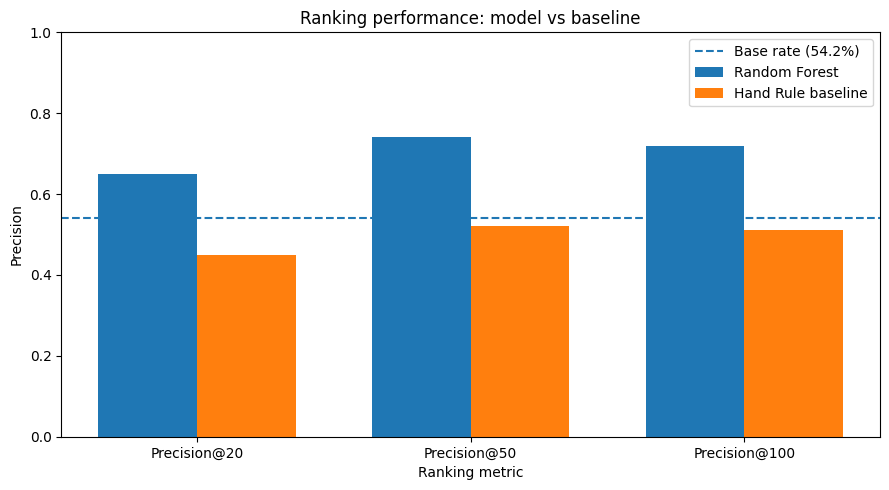

Saved: /content/flyrank-ml-internship/docs/assets/precision_vs_baseline.png


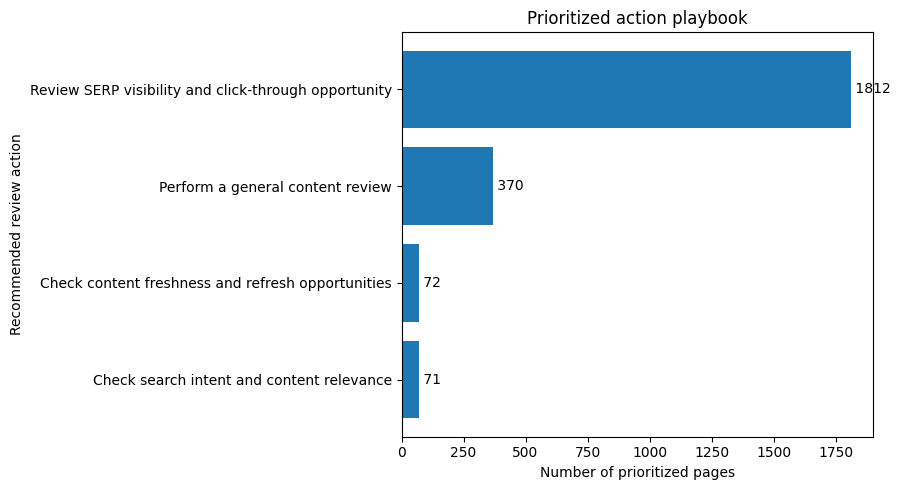

Saved: /content/flyrank-ml-internship/docs/assets/action_playbook.png

ARTIFACT CHECK
/content/flyrank-ml-internship/docs/assets/results_vs_baseline.csv: FOUND
/content/flyrank-ml-internship/docs/assets/precision_vs_baseline.png: FOUND
/content/flyrank-ml-internship/docs/assets/action_playbook.png: FOUND


In [14]:
# Section 7 — Artifacts the paper embeds

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Repository paths
repo_root = Path("/content/flyrank-ml-internship")
docs_dir = repo_root / "docs"
assets_dir = docs_dir / "assets"

assets_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Artifact 1 — Model vs baseline results table
# ------------------------------------------------------------

results_rows = []

for metric, values in results.items():
    results_rows.append({
        "metric": metric,
        "random_forest": values["Random Forest"],
        "hand_rule_baseline": values["Hand Rule"],
        "difference": values["Random Forest"] - values["Hand Rule"],
        "base_rate": base_rate,
    })

results_df = pd.DataFrame(results_rows)

results_csv = assets_dir / "results_vs_baseline.csv"
results_df.to_csv(results_csv, index=False)

print("RESULTS TABLE")
print(results_df.to_string(index=False))
print()
print(f"Saved: {results_csv}")

# ------------------------------------------------------------
# Artifact 2 — Precision@K chart
# ------------------------------------------------------------

metrics = list(results.keys())
model_scores = [results[m]["Random Forest"] for m in metrics]
baseline_scores = [results[m]["Hand Rule"] for m in metrics]

x = range(len(metrics))
width = 0.36

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    [i - width / 2 for i in x],
    model_scores,
    width,
    label="Random Forest"
)

ax.bar(
    [i + width / 2 for i in x],
    baseline_scores,
    width,
    label="Hand Rule baseline"
)

ax.axhline(
    base_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"Base rate ({base_rate:.1%})"
)

ax.set_title("Ranking performance: model vs baseline")
ax.set_xlabel("Ranking metric")
ax.set_ylabel("Precision")
ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.legend()

fig.tight_layout()

precision_chart = assets_dir / "precision_vs_baseline.png"
fig.savefig(precision_chart, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved: {precision_chart}")

# ------------------------------------------------------------
# Artifact 3 — Action playbook distribution chart
# ------------------------------------------------------------

action_labels = [item["action"] for item in recommendations]
action_counts = [item["pages"] for item in recommendations]

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(action_labels[::-1], action_counts[::-1])

ax.set_title("Prioritized action playbook")
ax.set_xlabel("Number of prioritized pages")
ax.set_ylabel("Recommended review action")

for i, value in enumerate(action_counts[::-1]):
    ax.text(value, i, f" {value}", va="center")

fig.tight_layout()

action_chart = assets_dir / "action_playbook.png"
fig.savefig(action_chart, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved: {action_chart}")

# ------------------------------------------------------------
# Final artifact check
# ------------------------------------------------------------

print()
print("ARTIFACT CHECK")
print("=" * 60)

for path in [results_csv, precision_chart, action_chart]:
    print(f"{path}: {'FOUND' if path.exists() else 'MISSING'}")

In [15]:
from pathlib import Path

repo_root = Path("/content/flyrank-ml-internship")
docs_dir = repo_root / "docs"
docs_dir.mkdir(parents=True, exist_ok=True)

html = r"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Which Content Pages Should Be Prioritized for Review?</title>
<meta name="description" content="A machine learning decision-support study for prioritizing declining content pages for editorial review.">

<style>
:root {
  --bg: #f7f7f5;
  --card: #ffffff;
  --text: #1d1d1f;
  --muted: #626262;
  --line: #ddddda;
  --accent: #2457a6;
  --accent-soft: #eaf0fb;
}

* {
  box-sizing: border-box;
}

html {
  scroll-behavior: smooth;
}

body {
  margin: 0;
  background: var(--bg);
  color: var(--text);
  font-family: Inter, -apple-system, BlinkMacSystemFont, "Segoe UI",
               Roboto, Helvetica, Arial, sans-serif;
  line-height: 1.65;
}

main {
  max-width: 1050px;
  margin: 0 auto;
  padding: 40px 22px 80px;
}

.hero {
  padding: 55px 0 45px;
  border-bottom: 1px solid var(--line);
}

.kicker {
  font-size: 0.82rem;
  font-weight: 700;
  letter-spacing: 0.12em;
  text-transform: uppercase;
  color: var(--accent);
}

h1 {
  font-size: clamp(2.2rem, 5vw, 4.2rem);
  line-height: 1.08;
  letter-spacing: -0.04em;
  max-width: 900px;
  margin: 14px 0 24px;
}

.subtitle {
  font-size: 1.18rem;
  color: var(--muted);
  max-width: 800px;
}

.abstract {
  margin-top: 30px;
  padding: 25px;
  background: var(--card);
  border: 1px solid var(--line);
  border-radius: 14px;
}

.abstract strong {
  display: block;
  margin-bottom: 8px;
}

nav {
  position: sticky;
  top: 0;
  z-index: 10;
  background: rgba(247,247,245,0.94);
  backdrop-filter: blur(8px);
  border-bottom: 1px solid var(--line);
}

.nav-inner {
  max-width: 1050px;
  margin: auto;
  padding: 12px 22px;
  display: flex;
  gap: 18px;
  overflow-x: auto;
}

nav a {
  color: var(--muted);
  text-decoration: none;
  white-space: nowrap;
  font-size: 0.9rem;
}

nav a:hover {
  color: var(--accent);
}

section {
  padding: 60px 0 20px;
}

h2 {
  font-size: 2rem;
  letter-spacing: -0.025em;
  margin-bottom: 14px;
}

h3 {
  margin-top: 32px;
}

p {
  max-width: 850px;
}

.card-grid {
  display: grid;
  grid-template-columns: repeat(auto-fit, minmax(220px, 1fr));
  gap: 16px;
  margin: 25px 0;
}

.card {
  background: var(--card);
  border: 1px solid var(--line);
  border-radius: 12px;
  padding: 20px;
}

.metric {
  font-size: 2rem;
  font-weight: 750;
}

.label {
  color: var(--muted);
  font-size: 0.92rem;
}

table {
  width: 100%;
  border-collapse: collapse;
  margin: 25px 0;
  background: var(--card);
  border: 1px solid var(--line);
}

th, td {
  padding: 13px 14px;
  text-align: left;
  border-bottom: 1px solid var(--line);
}

th {
  font-weight: 700;
}

figure {
  margin: 32px 0;
  padding: 20px;
  background: var(--card);
  border: 1px solid var(--line);
  border-radius: 14px;
}

figure img {
  width: 100%;
  height: auto;
  display: block;
}

figcaption {
  margin-top: 14px;
  color: var(--muted);
  font-size: 0.94rem;
}

.callout {
  padding: 22px 25px;
  border-left: 4px solid var(--accent);
  background: var(--accent-soft);
  margin: 25px 0;
}

ol li, ul li {
  margin: 9px 0;
}

a {
  color: var(--accent);
}

footer {
  margin-top: 70px;
  padding-top: 30px;
  border-top: 1px solid var(--line);
  color: var(--muted);
  font-size: 0.92rem;
}

.small {
  color: var(--muted);
  font-size: 0.9rem;
}

@media (max-width: 650px) {
  main {
    padding-left: 16px;
    padding-right: 16px;
  }

  .hero {
    padding-top: 35px;
  }

  table {
    font-size: 0.9rem;
  }

  th, td {
    padding: 10px 8px;
  }
}
</style>
</head>

<body>

<nav>
  <div class="nav-inner">
    <a href="#problem">Problem</a>
    <a href="#data">Data</a>
    <a href="#method">Methodology</a>
    <a href="#results">Results</a>
    <a href="#limitations">Limitations</a>
    <a href="#recommendations">Recommendations</a>
    <a href="#reproducibility">Reproducibility</a>
  </div>
</nav>

<main>

<header class="hero">
  <div class="kicker">FlyRank ML Internship · Research Artifact</div>

  <h1>Which Content Pages Should Be Prioritized for Review?</h1>

  <p class="subtitle">
    A machine learning decision-support approach for ranking content pages
    with evidence of declining search performance.
  </p>

  <div class="abstract">
    <strong>Abstract</strong>

    This study asks which content pages should be prioritized for editorial
    review so that editors can focus on pages with stronger evidence of
    declining search performance. The evaluation uses the FlyRank ML
    Internship anonymized 30,000-row modeling release, with declining pages
    defined from the observed trend direction. A Random Forest classifier is
    compared with a transparent hand-written rule using a client-grouped
    holdout containing 2,325 pages from six held-out clients. On that same
    holdout, the Random Forest achieved 74% Precision@50 versus 52% for the
    hand-written baseline, with a 54.21% overall declining-page base rate.
    The result is intended as directional decision support for editorial
    triage rather than a guarantee of future traffic recovery or business
    impact.
  </div>
</header>

<section id="problem">
  <h2>1. Introduction / Problem</h2>

  <p>
    Editors rarely have unlimited time to review every content page.
    The practical problem is therefore not simply identifying whether a
    page is declining, but deciding which pages deserve attention first.
  </p>

  <p>
    This project treats that as a ranking problem: produce a prioritized
    review queue so that editors can investigate the pages with stronger
    evidence of decline before spending time on lower-priority pages.
  </p>

  <div class="callout">
    <strong>Research question:</strong><br>
    Which content pages should be prioritized for review so that editors
    can focus on the pages with the highest potential for improvement?
  </div>
</section>

<section id="data">
  <h2>2. Data</h2>

  <div class="card-grid">
    <div class="card">
      <div class="metric">30,000</div>
      <div class="label">pages in the modeling release</div>
    </div>

    <div class="card">
      <div class="metric">16,262</div>
      <div class="label">pages labeled declining</div>
    </div>

    <div class="card">
      <div class="metric">54.21%</div>
      <div class="label">declining-page base rate</div>
    </div>

    <div class="card">
      <div class="metric">2,325</div>
      <div class="label">pages in the held-out evaluation set</div>
    </div>
  </div>

  <p>
    The modeling work uses the anonymized content-refresh release supplied
    with the FlyRank ML Internship repository. The raw modeling file is
    <code>data/raw/content_refresh_anonymized.csv</code>.
  </p>

  <p>
    The release contains page-level observations used to construct the
    modeling features and declining-page label. The final feature vector
    contains 26 model features after excluding target-derived information.
  </p>

  <p>
    This paper reports the 30,000-row modeling release used for the
    validated model. It does not claim that the model was trained or
    validated on the separate full warehouse release.
  </p>

  <p>
    To keep the artifact public-safe, client names and identifying details,
    raw search queries, private URLs, and other identifying information are
    not reported.
  </p>

  <p class="small">
    Date-window note: the public modeling artifact does not expose a
    separately verified calendar date range for this 30,000-row release,
    so no unverified date range is claimed here.
  </p>
</section>

<section id="method">
  <h2>3. Methodology</h2>

  <h3>Label</h3>

  <p>
    The target is <code>is_declining_label</code>, defined from
    <code>trend_direction == "down"</code>.
  </p>

  <h3>Features</h3>

  <p>
    The model uses the validated feature set produced during the internship.
    Target-derived fields were excluded from the final model features.
    In particular, <code>trend_direction</code> and <code>trend_pct</code>
    were not used as predictors because the target is derived from the
    observed trend direction.
  </p>

  <h3>Model and baseline</h3>

  <p>
    The final model is a Random Forest classifier. Its comparison point is
    a transparent hand-written rule developed earlier in the internship.
  </p>

  <h3>Validation design</h3>

  <p>
    Evaluation uses a client-grouped holdout. Six clients are held out,
    producing a 2,325-page test set. Pages from held-out clients are kept
    out of training so that the evaluation measures performance on unseen
    clients rather than randomly mixing pages from the same clients.
  </p>

  <h3>Leakage checks</h3>

  <p>
    The validation audit checked the final feature set for direct
    target-derived fields. The audit found no direct target leakage in the
    final feature list, while recognizing that feature exclusion alone
    cannot prove that every possible form of leakage is absent.
  </p>
</section>

<section id="results">
  <h2>4. Results</h2>

  <p>
    The key result is a ranking comparison on the same client-grouped
    holdout. Precision@K measures the share of pages in the top-K ranked
    pages that are labeled as declining.
  </p>

  <table>
    <thead>
      <tr>
        <th>Metric</th>
        <th>Random Forest</th>
        <th>Hand Rule</th>
        <th>Difference</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td>Precision@20</td>
        <td>65%</td>
        <td>45%</td>
        <td>+20 percentage points</td>
      </tr>
      <tr>
        <td>Precision@50</td>
        <td><strong>74%</strong></td>
        <td>52%</td>
        <td><strong>+22 percentage points</strong></td>
      </tr>
      <tr>
        <td>Precision@100</td>
        <td>72%</td>
        <td>51%</td>
        <td>+21 percentage points</td>
      </tr>
    </tbody>
  </table>

  <figure>
    <img src="assets/precision_vs_baseline.png"
         alt="Bar chart comparing Random Forest and hand-written rule Precision at 20, 50 and 100, with the base rate shown.">
    <figcaption>
      <strong>Takeaway:</strong> The Random Forest ranks declining pages more
      strongly than the hand-written baseline at all three evaluation depths
      on the client-grouped holdout.
    </figcaption>
  </figure>

  <div class="callout">
    <strong>Headline finding:</strong>
    At Precision@50, the Random Forest reached 74%, compared with 52% for
    the hand-written rule — a 22 percentage-point difference on the same
    unseen-client holdout.
  </div>

  <p>
    The 54.21% declining-page base rate is shown for context. The result is
    therefore not presented as ordinary classification accuracy; it is a
    ranking result for editorial triage.
  </p>
</section>

<section id="limitations">
  <h2>5. Limitations & Honest Framing</h2>

  <ul>
    <li>
      The evaluation uses the 30,000-row anonymized modeling release,
      not the separate full warehouse release.
    </li>
    <li>
      The target identifies pages whose observed trend direction is down;
      it does not measure whether an editorial intervention will cause
      recovery.
    </li>
    <li>
      The validation uses six held-out clients, so performance may differ
      for clients or data distributions not represented in this evaluation.
    </li>
    <li>
      Precision@K measures ranking quality for identifying declining pages;
      it is not a measure of causal impact, traffic lift, or business revenue.
    </li>
    <li>
      The model should be used as directional decision support for editorial
      prioritization, not as an autonomous decision-maker.
    </li>
    <li>
      The leakage audit found no direct target-derived fields in the final
      feature set, but feature exclusion alone cannot prove that every
      possible form of leakage is absent.
    </li>
  </ul>
</section>

<section id="recommendations">
  <h2>6. Ranked Recommendations</h2>

  <p>
    The model's output was turned into an action playbook rather than a
    claim that every page requires the same intervention.
  </p>

  <ol>
    <li>
      <strong>Review SERP visibility and click-through opportunity — 1,812 pages.</strong>
      This was the largest action category in the prioritized queue and is
      therefore the first practical review path.
    </li>

    <li>
      <strong>Perform a general content review — 370 pages.</strong>
      Pages without a more specific dominant reason can still warrant
      editorial investigation when their ranking score is high.
    </li>

    <li>
      <strong>Check content freshness and refresh opportunities — 72 pages.</strong>
      This smaller group can be investigated for outdated or refreshable
      content.
    </li>

    <li>
      <strong>Check search intent and content relevance — 71 pages.</strong>
      These pages can be reviewed for alignment between the content and
      the search intent they target.
    </li>
  </ol>

  <figure>
    <img src="assets/action_playbook.png"
         alt="Horizontal bar chart showing the four ranked editorial action categories.">
    <figcaption>
      <strong>Takeaway:</strong> Most prioritized pages fall into the SERP
      visibility and click-through review category, giving editors a clear
      first-pass action queue.
    </figcaption>
  </figure>

  <div class="callout">
    <strong>Recommended operating principle:</strong>
    Use the model as a triage mechanism. Start with the highest-ranked pages,
    investigate the suggested action category, and make editorial decisions
    only after human review.
  </div>
</section>

<section id="reproducibility">
  <h2>7. Reproducibility</h2>

  <p>
    The analysis is documented in the project repository and can be
    inspected through the notebooks used during the internship.
  </p>

  <div class="card-grid">
    <div class="card">
      <strong>Repository</strong>
      <p>
        <a href="https://github.com/pskarthikk/flyrank-ml-internship">
          GitHub repository
        </a>
      </p>
    </div>

    <div class="card">
      <strong>Validation audit</strong>
      <p>
        <a href="https://github.com/pskarthikk/flyrank-ml-internship/blob/main/work/notebooks/w06_validation_audit.ipynb">
          Week 6 validation notebook
        </a>
      </p>
    </div>

    <div class="card">
      <strong>Action playbook</strong>
      <p>
        <a href="https://github.com/pskarthikk/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb">
          Week 7 action-playbook notebook
        </a>
      </p>
    </div>

    <div class="card">
      <strong>Capstone</strong>
      <p>
        <a href="https://github.com/pskarthikk/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb">
          Week 8 capstone notebook
        </a>
      </p>
    </div>
  </div>

  <p>
    The validated client-grouped split uses random seed 42. The notebook
    contains the executable methodology, results, and generated artifacts.
  </p>
</section>

<section id="acknowledgments">
  <h2>8. Acknowledgments & Data Credit</h2>

  <p>
    Built on the
    <a href="https://flyrank.ai">FlyRank ML Internship dataset</a>.
  </p>

  <p>
    Thanks to the FlyRank ML Internship for providing the dataset,
    research workflow, and problem context used for this project.
  </p>
</section>

<footer>
  <p>
    Research artifact · FlyRank ML Internship · Machine Learning · Week 8
  </p>
  <p>
    This page reports observed evaluation results and is intended for
    transparent, reproducible decision support.
  </p>
</footer>

</main>
</body>
</html>
"""

index_path = docs_dir / "index.html"
index_path.write_text(html, encoding="utf-8")

print(f"Created: {index_path}")
print(f"Exists: {index_path.exists()}")
print(f"Size: {index_path.stat().st_size:,} bytes")

Created: /content/flyrank-ml-internship/docs/index.html
Exists: True
Size: 15,628 bytes


In [16]:
from pathlib import Path
import re

repo_root = Path("/content/flyrank-ml-internship")
docs_dir = repo_root / "docs"
index_path = docs_dir / "index.html"

html = index_path.read_text(encoding="utf-8")

required_sections = [
    "Introduction / Problem",
    "Data",
    "Methodology",
    "Results",
    "Limitations & Honest Framing",
    "Ranked Recommendations",
    "Reproducibility",
    "Acknowledgments & Data Credit",
]

required_assets = [
    docs_dir / "assets" / "precision_vs_baseline.png",
    docs_dir / "assets" / "action_playbook.png",
    docs_dir / "assets" / "results_vs_baseline.csv",
]

print("PUBLIC PAPER AUDIT")
print("=" * 60)

print(f"index.html exists: {index_path.exists()}")

print("\nRequired sections:")
for section in required_sections:
    print(f"- {section}: {'PASS' if section in html else 'MISSING'}")

print("\nRequired assets:")
for asset in required_assets:
    print(f"- {asset.name}: {'PASS' if asset.exists() else 'MISSING'}")

print("\nPublic-safety scan:")
safety_terms = [
    "private query",
    "client name",
    "client names",
    "private URL",
    "private URLs",
    "password",
    "token",
    "api_key",
    "secret",
]

for term in safety_terms:
    found = term.lower() in html.lower()
    print(f"- '{term}': {'FOUND — REVIEW' if found else 'not found'}")

print("\nRequired FlyRank credit:")
print(
    "- FlyRank link: "
    + ("PASS" if "https://flyrank.ai" in html else "MISSING")
)

print("\nRequired result values:")
result_checks = [
    "74%",
    "52%",
    "54.21%",
    "65%",
    "45%",
    "72%",
    "51%",
]

for value in result_checks:
    print(f"- {value}: {'PASS' if value in html else 'MISSING'}")

print("\nRelative image paths:")
image_paths = re.findall(r'<img[^>]+src="([^"]+)"', html)

for path in image_paths:
    print(f"- {path}: {'PASS' if not path.startswith('/') else 'ABSOLUTE PATH'}")

print("\nAUDIT COMPLETE")

PUBLIC PAPER AUDIT
index.html exists: True

Required sections:
- Introduction / Problem: PASS
- Data: PASS
- Methodology: PASS
- Results: PASS
- Limitations & Honest Framing: PASS
- Ranked Recommendations: PASS
- Reproducibility: PASS
- Acknowledgments & Data Credit: PASS

Required assets:
- precision_vs_baseline.png: PASS
- action_playbook.png: PASS
- results_vs_baseline.csv: PASS

Public-safety scan:
- 'private query': not found
- 'client name': FOUND — REVIEW
- 'client names': FOUND — REVIEW
- 'private URL': FOUND — REVIEW
- 'private URLs': FOUND — REVIEW
- 'password': not found
- 'token': not found
- 'api_key': not found
- 'secret': not found

Required FlyRank credit:
- FlyRank link: PASS

Required result values:
- 74%: PASS
- 52%: PASS
- 54.21%: PASS
- 65%: PASS
- 45%: PASS
- 72%: PASS
- 51%: PASS

Relative image paths:
- assets/precision_vs_baseline.png: PASS
- assets/action_playbook.png: PASS

AUDIT COMPLETE


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.